In [ ]:
import requests
from config import GITHUB_TOKEN

distinct_users = set()
page = 1

headers = {
    'Authorization': f'token {GITHUB_TOKEN}',  # Use the imported token here
    'Accept': 'application/vnd.github.v3+json',  # Optional: Specify the version of the API
}

while True:
    url = f'https://api.github.com/repos/obophenotype/cell-ontology/issues?state=all&per_page=100&page={page}'
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        issues = response.json()
        if not issues:  # Exit if there are no more issues
            break
        for issue in issues:
            if 'user' in issue:
                distinct_users.add(issue['user']['login'])
        page += 1
    else:
        print(f"Failed to retrieve issues: {response.status_code}")
        print(response.json()) 
        break


bonitalam
jahilton
Caroline-99
mkeays
anitacaron
twhetzel
ssyeds3
zimmwe
maarten-devries
Alain-Gateau
cmpich
huawen-poppy
stevevanhooser
raymond-sanchez
lgcowell
ybradford
rachhuntley
Arlene-1998
tuli
KazuhiroNakagawa
GHAStVHenry
andreagaede
bgyori
dosumis
RiveraAndrea83
GoogleCodeExporter
pnejad
nnouspikel
erebboah
hkir-dev
gouttegd
rebeccafoulger
jonathanbona
jingangdidi
cthoyt
bherr2
noamrotenberg
rachadele
anna-anagnostop
bkmartinjr
LCCarmody
gabbysantos
dependabot[bot]
franasa
shiqi-yang
NatalieZelenka
noamiz5060
olgabot
krchristie
markwoon
sfexova
corismall
azankl
mshadbolt
AramKrol
mbernste
xnrxng
slaulederkind
jychien
minigel
paola-scibite
raymond91125
balhoff
jlparmley
avikdatta
LiNiMGI
mah11
krcurtis
AnnekarinaPerl
cebriggs7135
vjcitn
Tulasi08
scheuerm
meena74
dosumisu
lubianat
ANiknejad
vanaukenk
alanruttenberg
sebozzie
chenlingantelope
nicolevasilevsky
pgaudet
govekk
ukemi
nlharris
JArgasinska
stevewds
lfurrer
paulacalipho
amadeusX
cerivs
kalpanaps
MartaBenegas
Clare72
zoep

In [42]:
user_count = len(distinct_users)
print(f"Number of distinct users: {user_count}")


Number of distinct users: 136


# Issues Stats
Data generated 191125 and stored in data/issues-stats.csv

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

issues = pd.read_csv('../data/issues-stats.csv', sep='\t')

In [4]:
issues

,Year,Issues opened,Issues closed,Average response time (d),Median response time (d),Average TTC (d),Median TTC (d)
0,2018,31,22,1652,1454,1221,1312
1,2019,35,32,730,913,580,596
2,2020,138,118,434,69,184,38
3,2021,259,230,304,60,132,43
4,2022,157,143,165,28,59,22
5,2023,241,198,208,15,62,9
6,2024,331,260,148,45,65,19
7,2025,279,214,54,23,32,17


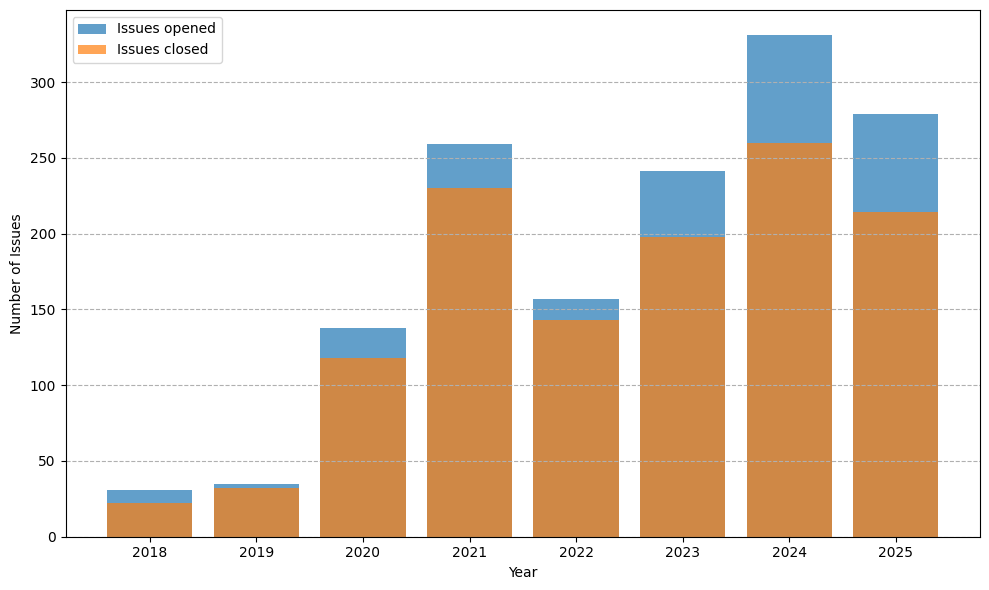

In [12]:
# Bar plot of issues close and open over years

bar_width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(issues['Year'], issues['Issues opened'], label='Issues opened', alpha=0.7)
plt.bar(issues['Year'], issues['Issues closed'], label='Issues closed', alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Number of Issues')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


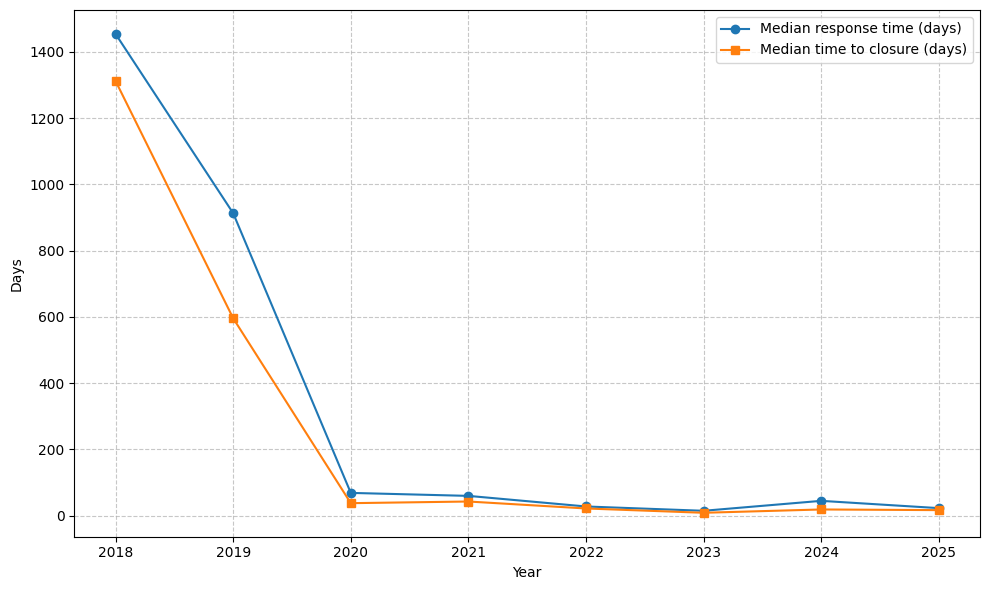

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(issues['Year'], issues['Median response time (d)'], marker='o', label='Median response time (days)')
plt.plot(issues['Year'], issues['Median TTC (d)'], marker='s', label='Median time to closure (days)')
# plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('Days')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()